# Dependencies (run in new session)
Always import first!

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import seaborn as sns
import scanpy as sc
import os
import math

In case something hasn't updated, replace script with your script name:

In [ ]:
import importlib
from scripts import script
importlib.reload(script)

# Load data (first session)

In [ ]:
from scripts.preprocessing import load_data, filter_by_area, filter_by_dapi, visualize_dapi, save_filtered

df = load_data("../data/processed/IHOPE26_LN_InstanSeq_modified.csv")
df = filter_by_area(df)
df = filter_by_dapi(df)
visualize_dapi(df)
save_filtered(df, "../data/processed/IHOPE26_LN_InstanSeq_filtered_outliers_TOY.csv")


# Normalization (first session)

In [ ]:
from scripts.transforms import arcsinh_transform, zscore_transform, plot_distributions
import pandas as pd

# Load filtered CSV
file_path = "../data/processed/IHOPE26_LN_InstanSeq_filtered_outliers_TOY.csv"
df = pd.read_csv(file_path)

# Define columns (markers) to transform
target_columns = [
    "CCR6: Mean", "CCR7: Mean", "CD107a: Mean", "CD11c: Mean", "CD14: Mean", "CD141: Mean",
    "CD163: Mean", "CD1c: Mean", "CD20: Mean", "CD21: Mean", "CD27: Mean", "CD31: Mean",
    "CD34: Mean", "CD38: Mean", "CD3e: Mean", "CD4: Mean", "CD40: Mean", "CD45: Mean",
    "CD45RA: Mean", "CD45RO: Mean", "CD57: Mean", "CD68: Mean", "CD69: Mean", "CD79a: Mean",
    "CD8: Mean", "Collagen IV: Mean", "CXCL13: Mean", "DAPI: Mean", "FOXP3: Mean",
    "Granzyme B: Mean", "HLA-DR: Mean", "ICOS: Mean", "IFNG: Mean", "Ki67: Mean", "LYVE1: Mean",
    "PD-1: Mean", "TCF-1: Mean", "Vimentin: Mean"
]

# Filter columns that exist in the DataFrame
columns_to_transform = [col for col in target_columns if col in df.columns]
metadata_columns = [col for col in df.columns if col not in columns_to_transform]

# Visualize original distributions
plot_distributions(df, columns_to_transform, title_prefix="Raw ", view=True)

# Apply arcsinh transformation
df_arcsinh, arcsinh_cols = arcsinh_transform(df, columns_to_transform, cofactor=5.0)

# Plot transformed distributions
plot_distributions(df_arcsinh, arcsinh_cols, title_prefix="Arcsinh (cf=5) ", view=True)

# Apply Z-score normalization
df_z, zscore_cols = zscore_transform(df, columns_to_transform)

# Plot Z-score distributions
plot_distributions(df_z, zscore_cols, title_prefix="Z-score ", view=True)

# Save transformed data
output_file = "../data/processed/IHOPE26_LN_InstanSeq_filtered_outliers_zscore_TOY.csv"
df_z[metadata_columns + zscore_cols].to_csv(output_file, index=False)
print(f"Saved Z-score normalized data to {output_file}")

# Normalization (new version)

Please select:

**input_file** – a file path for your raw data in csv format

**method** – "arcsinh" or "zscore"

**cofactor** – only if using arcsinh

The new file with normalized data will automatically be named after the input file, with the addition of normalization method and optional cofactor. Same goes for the plot of marker distributions.

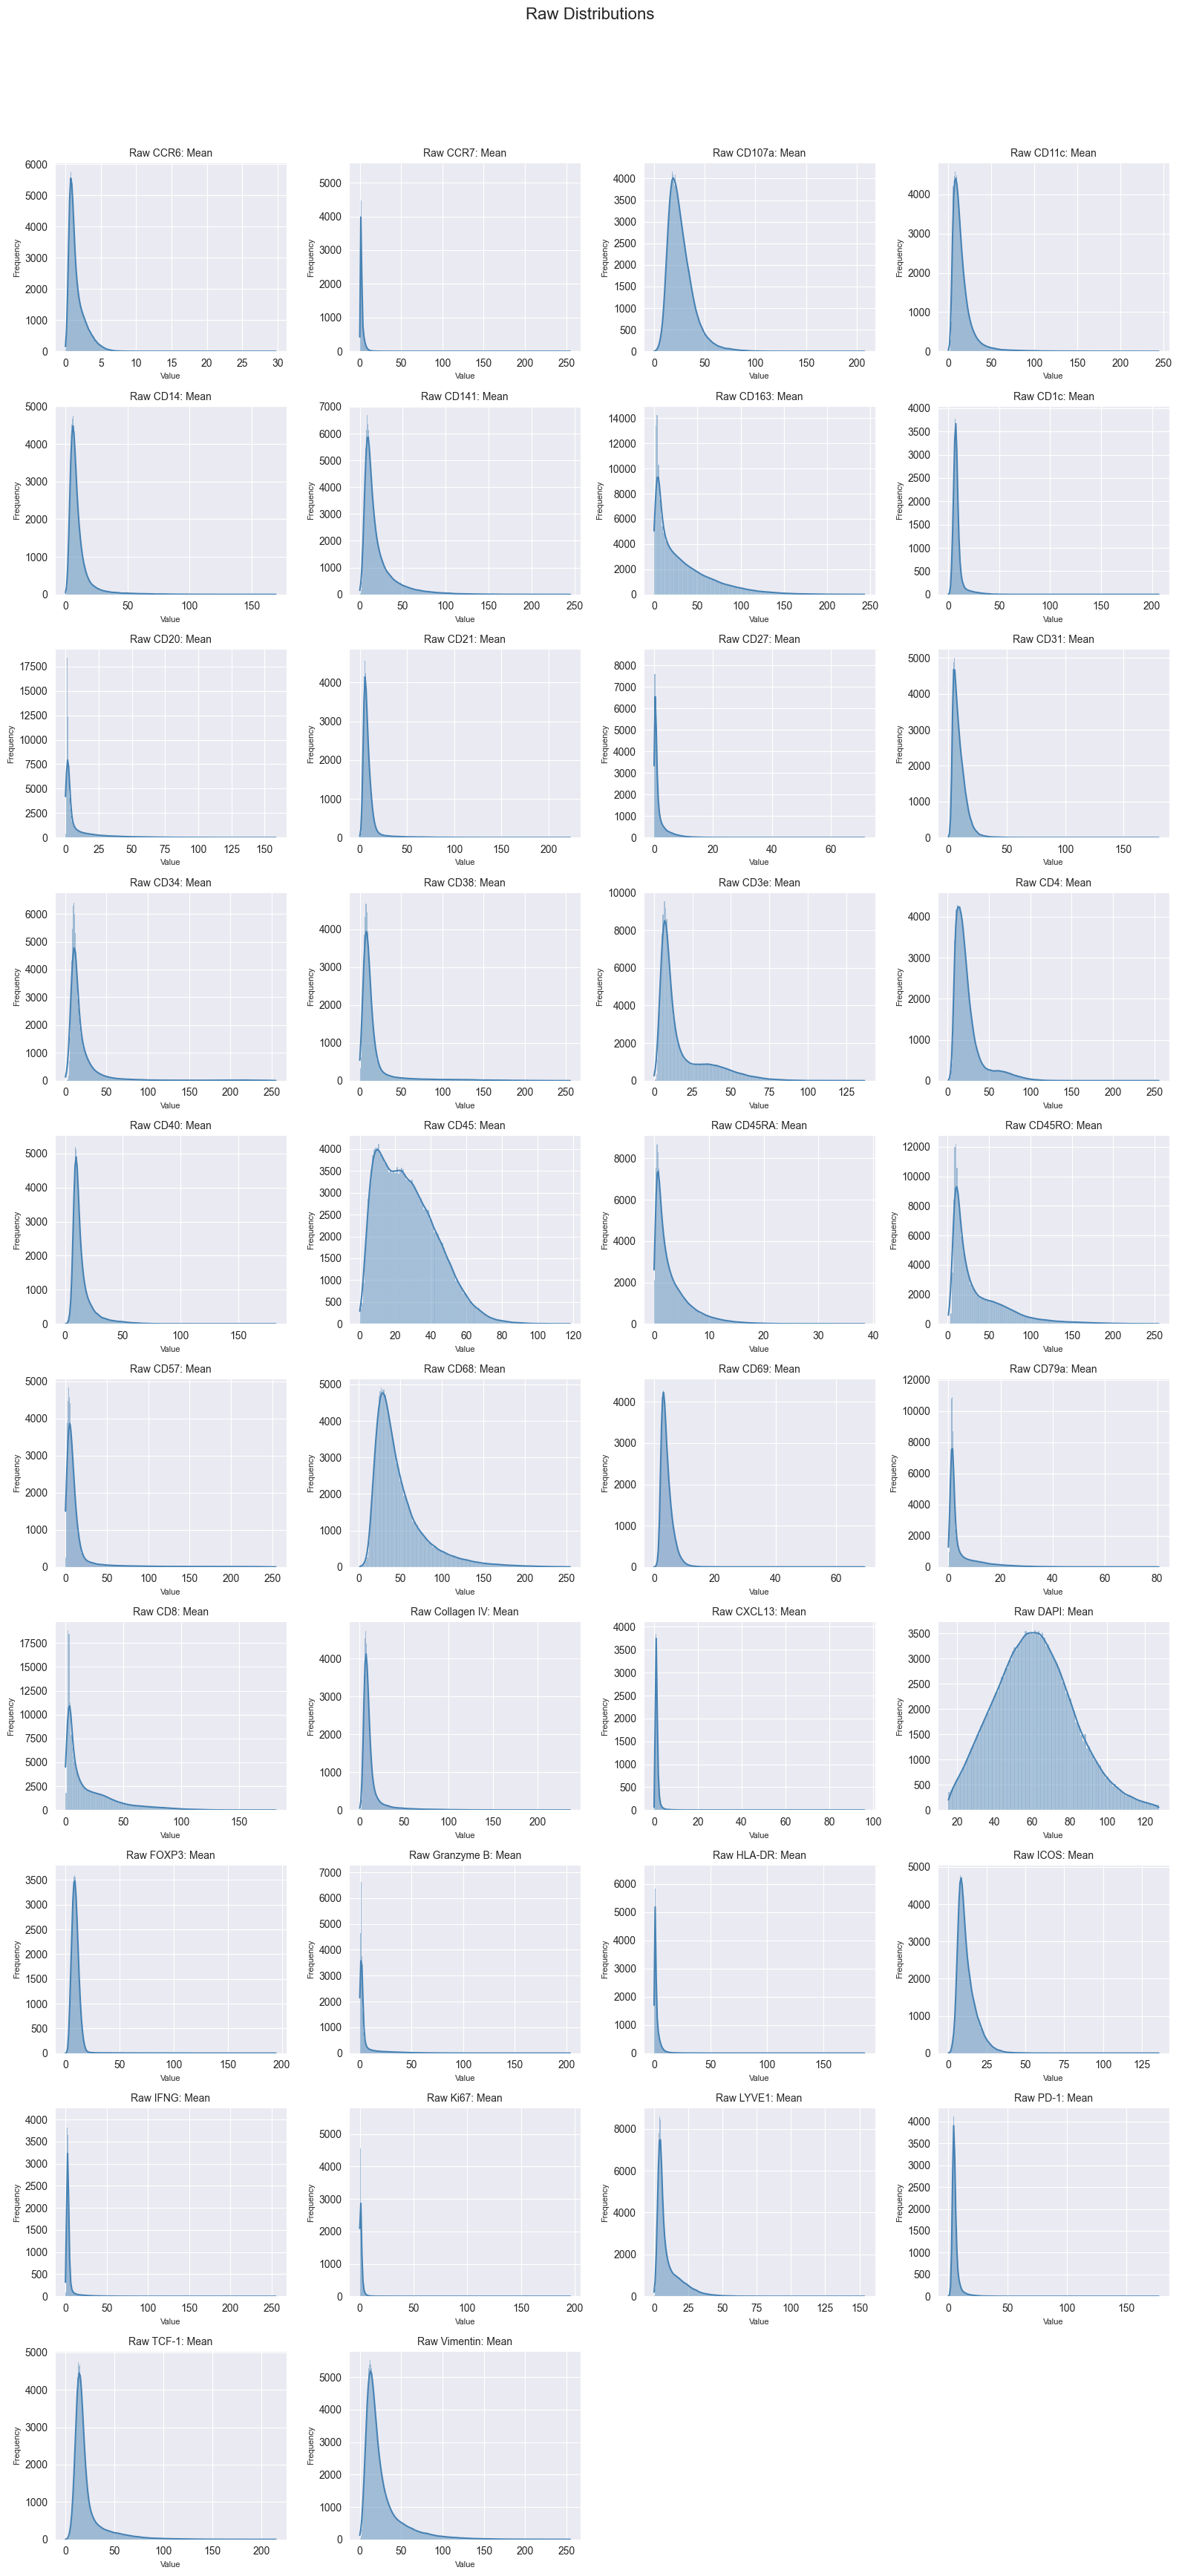

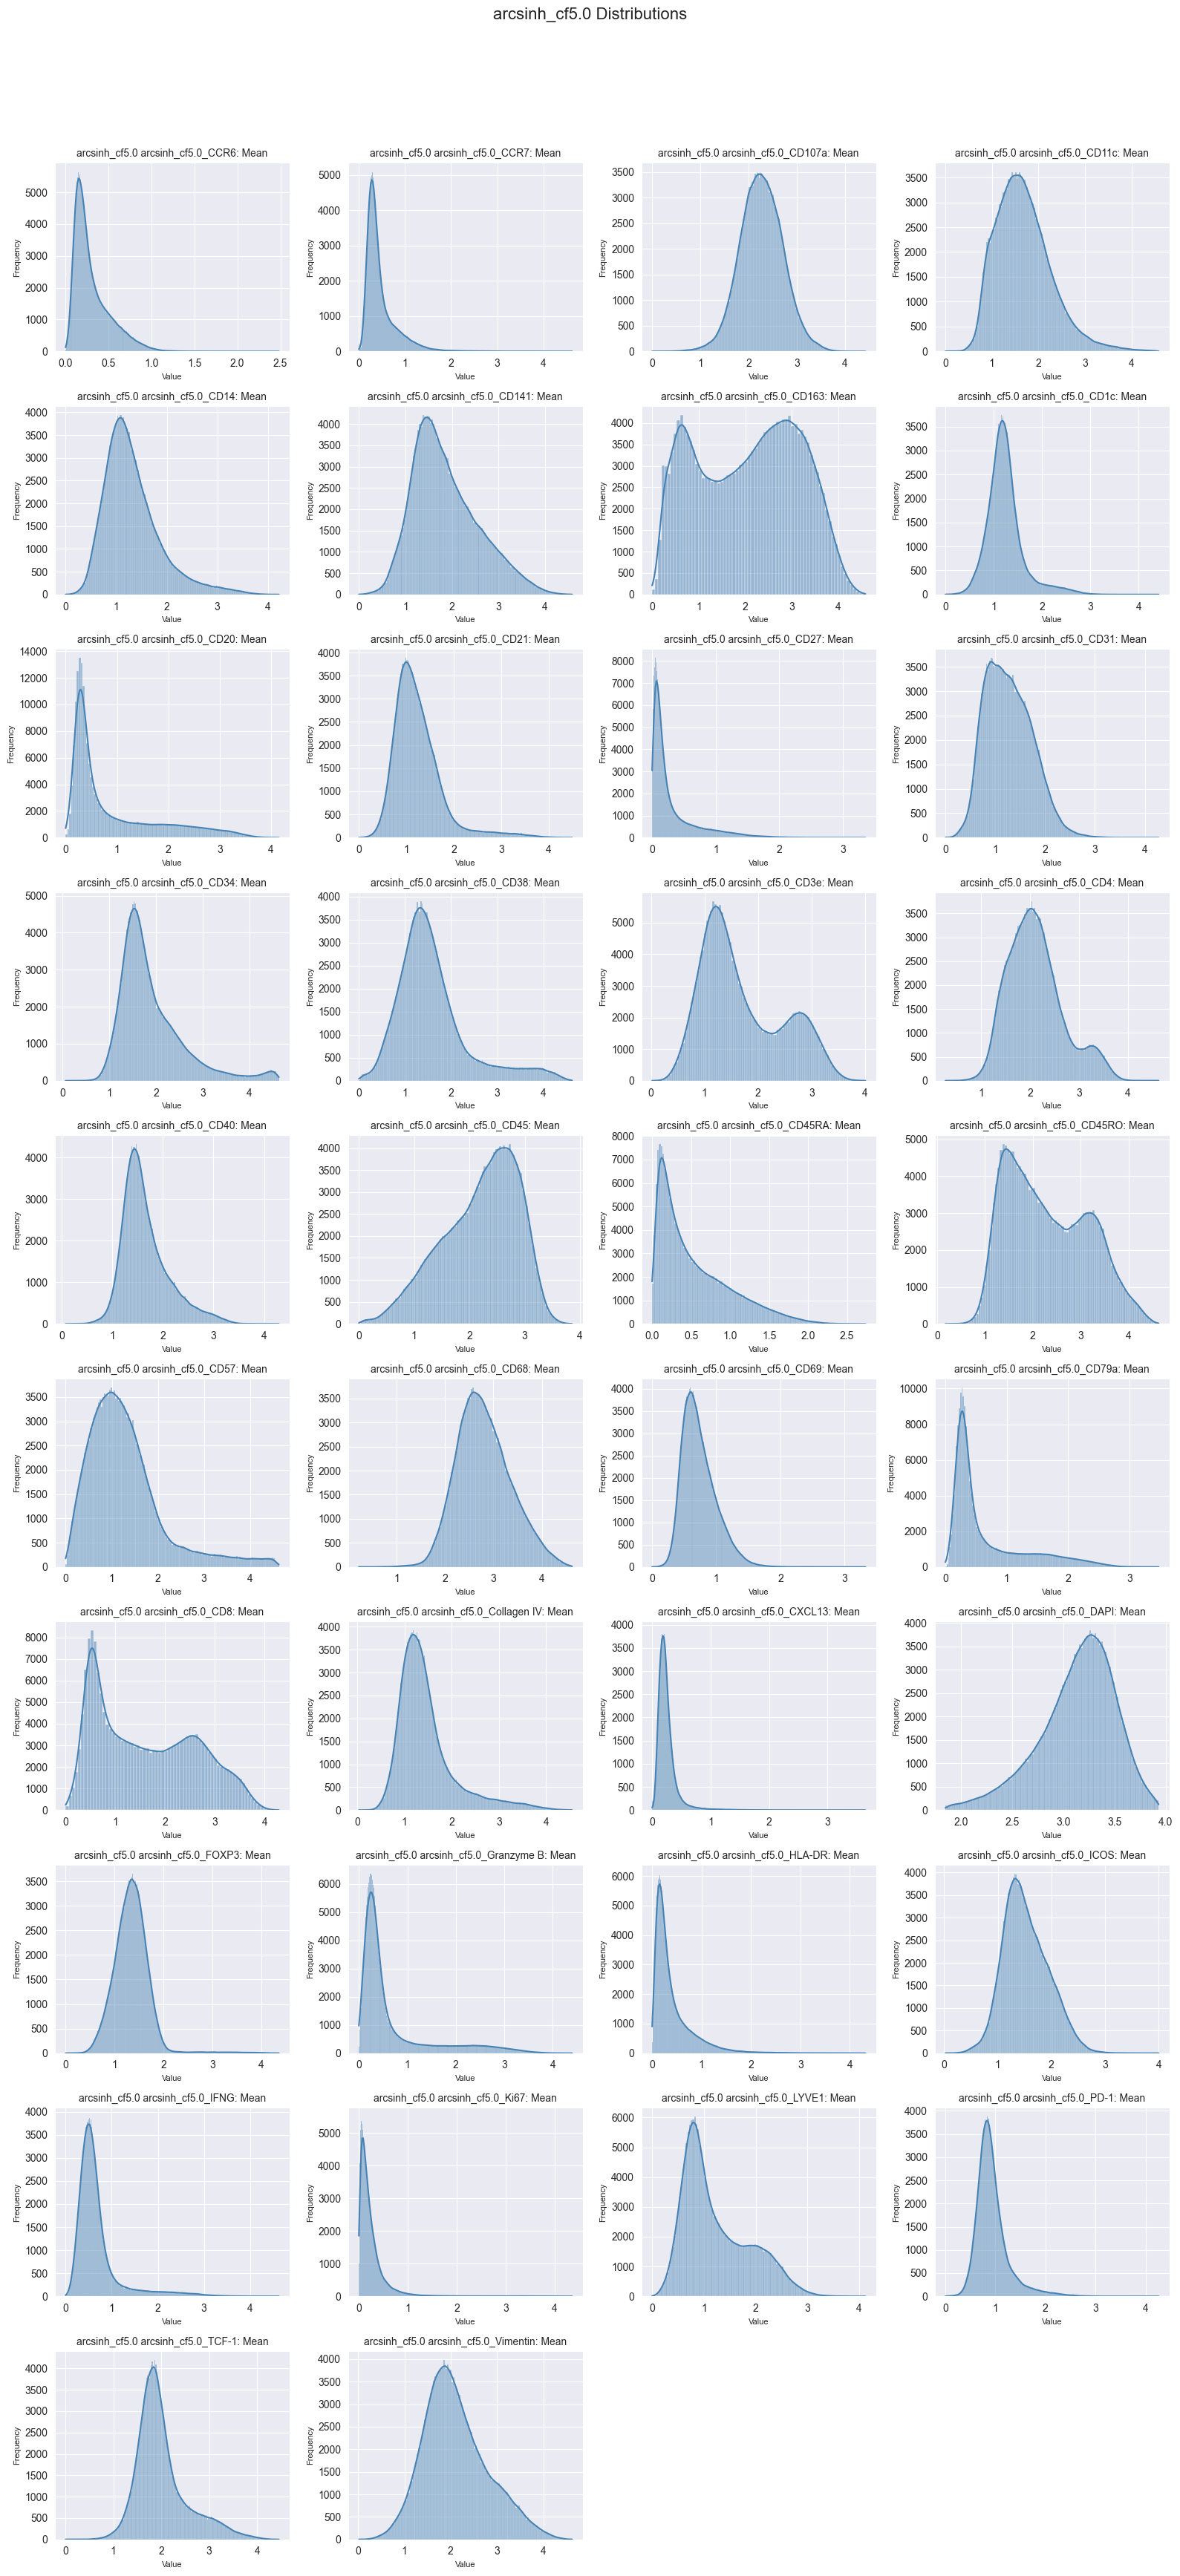

Saved transformed data to ../data/processed/IHOPE26_LN_InstanSeq_filtered_outliers_TOY_arcsinh_cf5.0.csv


In [54]:
from scripts.transforms import arcsinh_transform, zscore_transform, plot_distributions, apply_transform

# Define your file name, method and optional cofactor:
input_file = "../data/processed/IHOPE26_LN_InstanSeq_filtered_outliers_TOY.csv"
method = "arcsinh"
cofactor = 5.0

# Read input file
df = pd.read_csv(input_file)

# Apply the transform
df_transformed, new_cols, meta_cols, output_file = apply_transform(
    df,
    method=method,
    cofactor=cofactor,
    input_file=input_file
)

# Create AnnData object (start here in new session!)

In [58]:
# TODO wtf happened here

# Select all intensity columns (normalized or raw)
intensity_columns = [col for col in df.columns if col not in ['Object ID', 'Centroid X µm', 'Centroid Y µm', 'Area µm^2', 'Nucleus/Cell area ratio']]

# Dictionary to store counts of invalid values
invalid_counts = {}

for col in intensity_columns:
    nan_count = df[col].isna().sum()
    inf_count = np.isinf(df[col]).sum()
    total_invalid = nan_count + inf_count
    if total_invalid > 0:
        invalid_counts[col] = total_invalid

# Convert to pandas Series for easy viewing and sorting
invalid_summary = pd.Series(invalid_counts).sort_values(ascending=False)

print("Markers with missing or infinite values (count):")
print(invalid_summary)


Markers with missing or infinite values (count):
ICOS: Median               3782
Nucleus: IFNG: Median      3671
Nucleus: CD45RA: Median    2241
Nucleus: HLA-DR: Median    1870
Ki67: Median               1826
HLA-DR: Median             1477
Nucleus: CXCL13: Median    1147
CCR6: Median                973
CXCL13: Median              824
Nucleus: Circularity         80
dtype: int64


In [55]:
from scripts.preprocessing import load_data
from scripts.anndata_helpers import validate_dataframe, build_anndata

# Provide the path to the normalized CSV
file_path = "../data/processed/IHOPE26_LN_InstanSeq_filtered_outliers_TOY_arcsinh_cf5.0.csv"
df = load_data(file_path)

# Select intensity columns (normalized)
intensity_columns = [col for col in df.columns if col not in ['Object ID', 'Centroid X µm', 'Centroid Y µm', 'Area µm^2', 'Nucleus/Cell area ratio']]

obs_cols = ['Object ID', 'Centroid X µm', 'Centroid Y µm', 'Area µm^2', 'Nucleus/Cell area ratio']

df_clean = validate_dataframe(df, intensity_columns, obs_cols)
adata = build_anndata(df_clean, intensity_columns, obs_cols)

print(adata)
print(adata.obsm['spatial'].shape)

ValueError: Invalid values (NaN, Inf, -Inf) detected in intensity columns.

In [2]:
#new
from scripts.anndata_helpers import load_and_build_anndata

# Define metadata columns TODO move to script?
obs_cols = ['Object ID', 'Centroid X µm', 'Centroid Y µm', 'Area µm^2', 'Nucleus/Cell area ratio']

# Provide path to any CSV (raw or transformed)
file_path = "../data/processed/IHOPE26_LN_InstanSeq_filtered_outliers_TOY_arcsinh_cf5.0.csv"

# Load AnnData
adata = load_and_build_anndata(file_path, obs_cols)

print(adata)
print(adata.obsm['spatial'].shape)


AnnData object with n_obs × n_vars = 187097 × 152
    obs: 'Object ID', 'Centroid X µm', 'Centroid Y µm', 'Area µm^2', 'Nucleus/Cell area ratio'
    obsm: 'spatial'
(187097, 2)


In [60]:
from scripts import anndata_helpers
importlib.reload(anndata_helpers)

<module 'scripts.anndata_helpers' from '/Users/magnusberg/Documents/Internships/fall 2025/IHOPE_SpatialProteomics/scripts/anndata_helpers.py'>

In [5]:
#TODO: remove??

from scripts.preprocessing import load_data
from scripts.anndata_helpers import validate_dataframe, build_anndata

file_path = "../data/processed/IHOPE26_LN_InstanSeq_filtered_outliers_arcsinh.csv"
df = load_data(file_path)

# Choose 'zscore', 'arcsinh'
intensity_columns = [col for col in df.columns if 'arcsinh_' in col and col.endswith(': Mean')]
obs_cols = ['Object ID', 'Centroid X µm', 'Centroid Y µm', 'Area µm^2', 'Nucleus/Cell area ratio']

df_clean = validate_dataframe(df, intensity_columns, obs_cols)
adata = build_anndata(df_clean, intensity_columns, obs_cols)

print(adata)
print(adata.obsm['spatial'].shape)


FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/IHOPE26_LN_InstanSeq_filtered_outliers_arcsinh.csv'

In [3]:
print(adata.obs.columns)

Index(['Object ID', 'Centroid X µm', 'Centroid Y µm', 'Area µm^2',
       'Nucleus/Cell area ratio'],
      dtype='object')


In [6]:
print(adata.var)
#print(type(adata.X))
#print(adata.X[:5, :5])

Empty DataFrame
Columns: []
Index: [Nucleus: DAPI, Nucleus: Ki67, Nucleus: CD69, Nucleus: CD107a, Nucleus: CD27, Nucleus: CD79a, Nucleus: FOXP3, Nucleus: CD38, Nucleus: CD3e, Nucleus: CD163, Nucleus: TCF-1, Nucleus: CD21, Nucleus: CD45RA, Nucleus: CXCL13, Nucleus: IFNG, Nucleus: CCR7, Nucleus: CD57, Nucleus: CD20, Nucleus: CD34, Nucleus: LYVE1, Nucleus: CD40, Nucleus: CD141, Nucleus: PD-1, Nucleus: Granzyme B, Nucleus: CD31, Nucleus: ICOS, Nucleus: CD11c, Nucleus: CD14, Nucleus: CCR6, Nucleus: CD45RO, Nucleus: CD45, Nucleus: CD1c, Nucleus: CD4, Nucleus: CD8, Nucleus: HLA-DR, Nucleus: Collagen IV, Nucleus: Vimentin, Nucleus: CD68, Cytoplasm: DAPI, Cytoplasm: Ki67, Cytoplasm: CD69, Cytoplasm: CD107a, Cytoplasm: CD27, Cytoplasm: CD79a, Cytoplasm: FOXP3, Cytoplasm: CD38, Cytoplasm: CD3e, Cytoplasm: CD163, Cytoplasm: TCF-1, Cytoplasm: CD21, Cytoplasm: CD45RA, Cytoplasm: CXCL13, Cytoplasm: IFNG, Cytoplasm: CCR7, Cytoplasm: CD57, Cytoplasm: CD20, Cytoplasm: CD34, Cytoplasm: LYVE1, Cytoplasm: 

# Clustering
Adapted from Natthaphong Kaewkam.

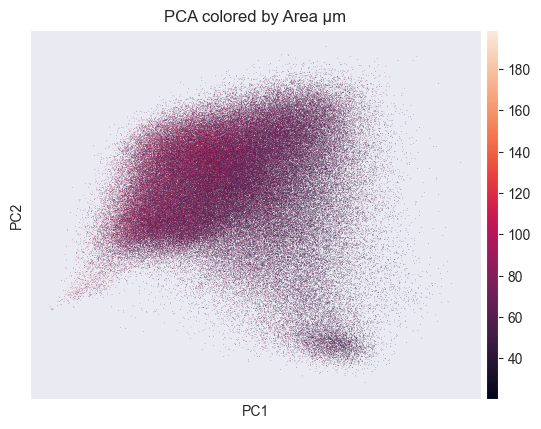

/var/folders/30/65bd79gx1xq3x7x5jng74jrh0000gn/T/ipykernel_2615/1882166484.py:9: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5)


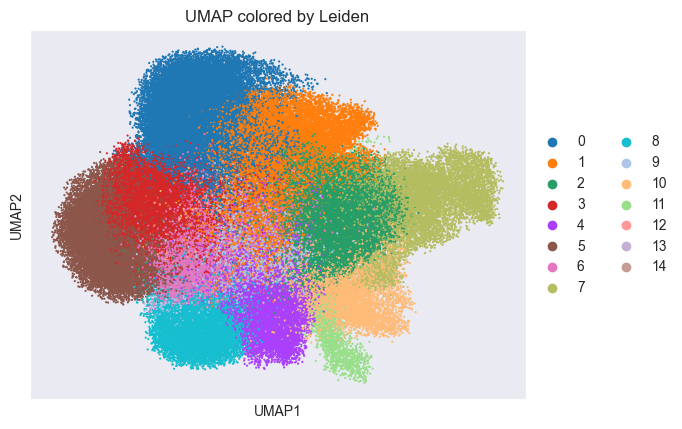

In [47]:
sc.tl.pca(adata)

sc.pl.pca(adata, color='Area µm^2', title='PCA colored by Area µm')

sc.pp.neighbors(adata, n_neighbors=10, use_rep='X_pca')

sc.tl.umap(adata, min_dist=0.5, spread=0.3)

sc.tl.leiden(adata, resolution=0.5)

sc.pl.umap(adata, color='leiden', title='UMAP colored by Leiden', size=10)


--- Plotting spatial distribution of clusters ---


/var/folders/30/65bd79gx1xq3x7x5jng74jrh0000gn/T/ipykernel_2615/2232884734.py:9: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata,


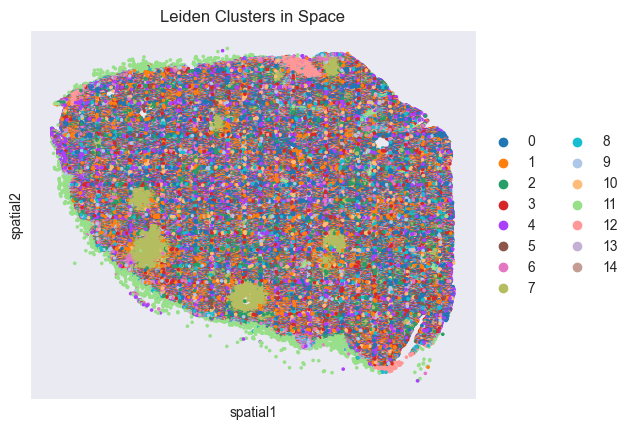


Simplified cluster characterization complete.


In [48]:
# Spatial Visualization of Clusters
print("\n--- Plotting spatial distribution of clusters ---")
if 'spatial' in adata.obsm and 'leiden' in adata.obs.columns:
    spatial_colors = ['leiden']
    # Add annotated types
    if 'cell_type_annotation' in adata.obs.columns:
        spatial_colors.append('cell_type_annotation')

    sc.pl.spatial(adata,
                  color=spatial_colors,
                  spot_size=50, # Adjust spot_size
                  title=['Leiden Clusters in Space', 'Annotated Types in Space'][:len(spatial_colors)])
else:
    print("Skipping spatial plot ('spatial' coords or 'leiden' column missing).")

print("\nSimplified cluster characterization complete.")

# Threshold-based cell type annotation

First fit appropriate distributions to the marker intensities (uni- or bimodal):

In [42]:
#TODO move a lot of this to script!

from scripts.annotation import (
    fit_gmm_models,
    compute_threshold,
    compute_positivity_matrix,
    add_positivity_to_adata
)

# Compute thresholds and best GMMs for all markers
thresholds = {}
best_gmms = {}

for i, marker in enumerate(adata.var_names):
    x = np.asarray(adata.X[:, i]).flatten()

    # Fit GMMs and select best by BIC
    best_model, best_k = fit_gmm_models(x, random_state=0)

    # Compute threshold (bimodal = intersection, unimodal = quantile)
    thr = compute_threshold(x, random_state=0)

    thresholds[marker] = thr
    best_gmms[marker] = best_model

# Compute boolean positivity matrix
df_bool, _ = compute_positivity_matrix(adata)

# Add boolean matrix and thresholds to AnnData
adata = add_positivity_to_adata(adata, df_bool, thresholds)


Plot the fits and thresholds:

Summary: 1 unimodal markers, 37 bimodal markers
Unimodal markers: ['CD107a']
Bimodal markers: ['CCR6', 'CCR7', 'CD11c', 'CD14', 'CD141', 'CD163', 'CD1c', 'CD20', 'CD21', 'CD27', 'CD31', 'CD34', 'CD38', 'CD3e', 'CD4', 'CD40', 'CD45', 'CD45RA', 'CD45RO', 'CD57', 'CD68', 'CD69', 'CD79a', 'CD8', 'Collagen IV', 'CXCL13', 'DAPI', 'FOXP3', 'Granzyme B', 'HLA-DR', 'ICOS', 'IFNG', 'Ki67', 'LYVE1', 'PD-1', 'TCF-1', 'Vimentin']


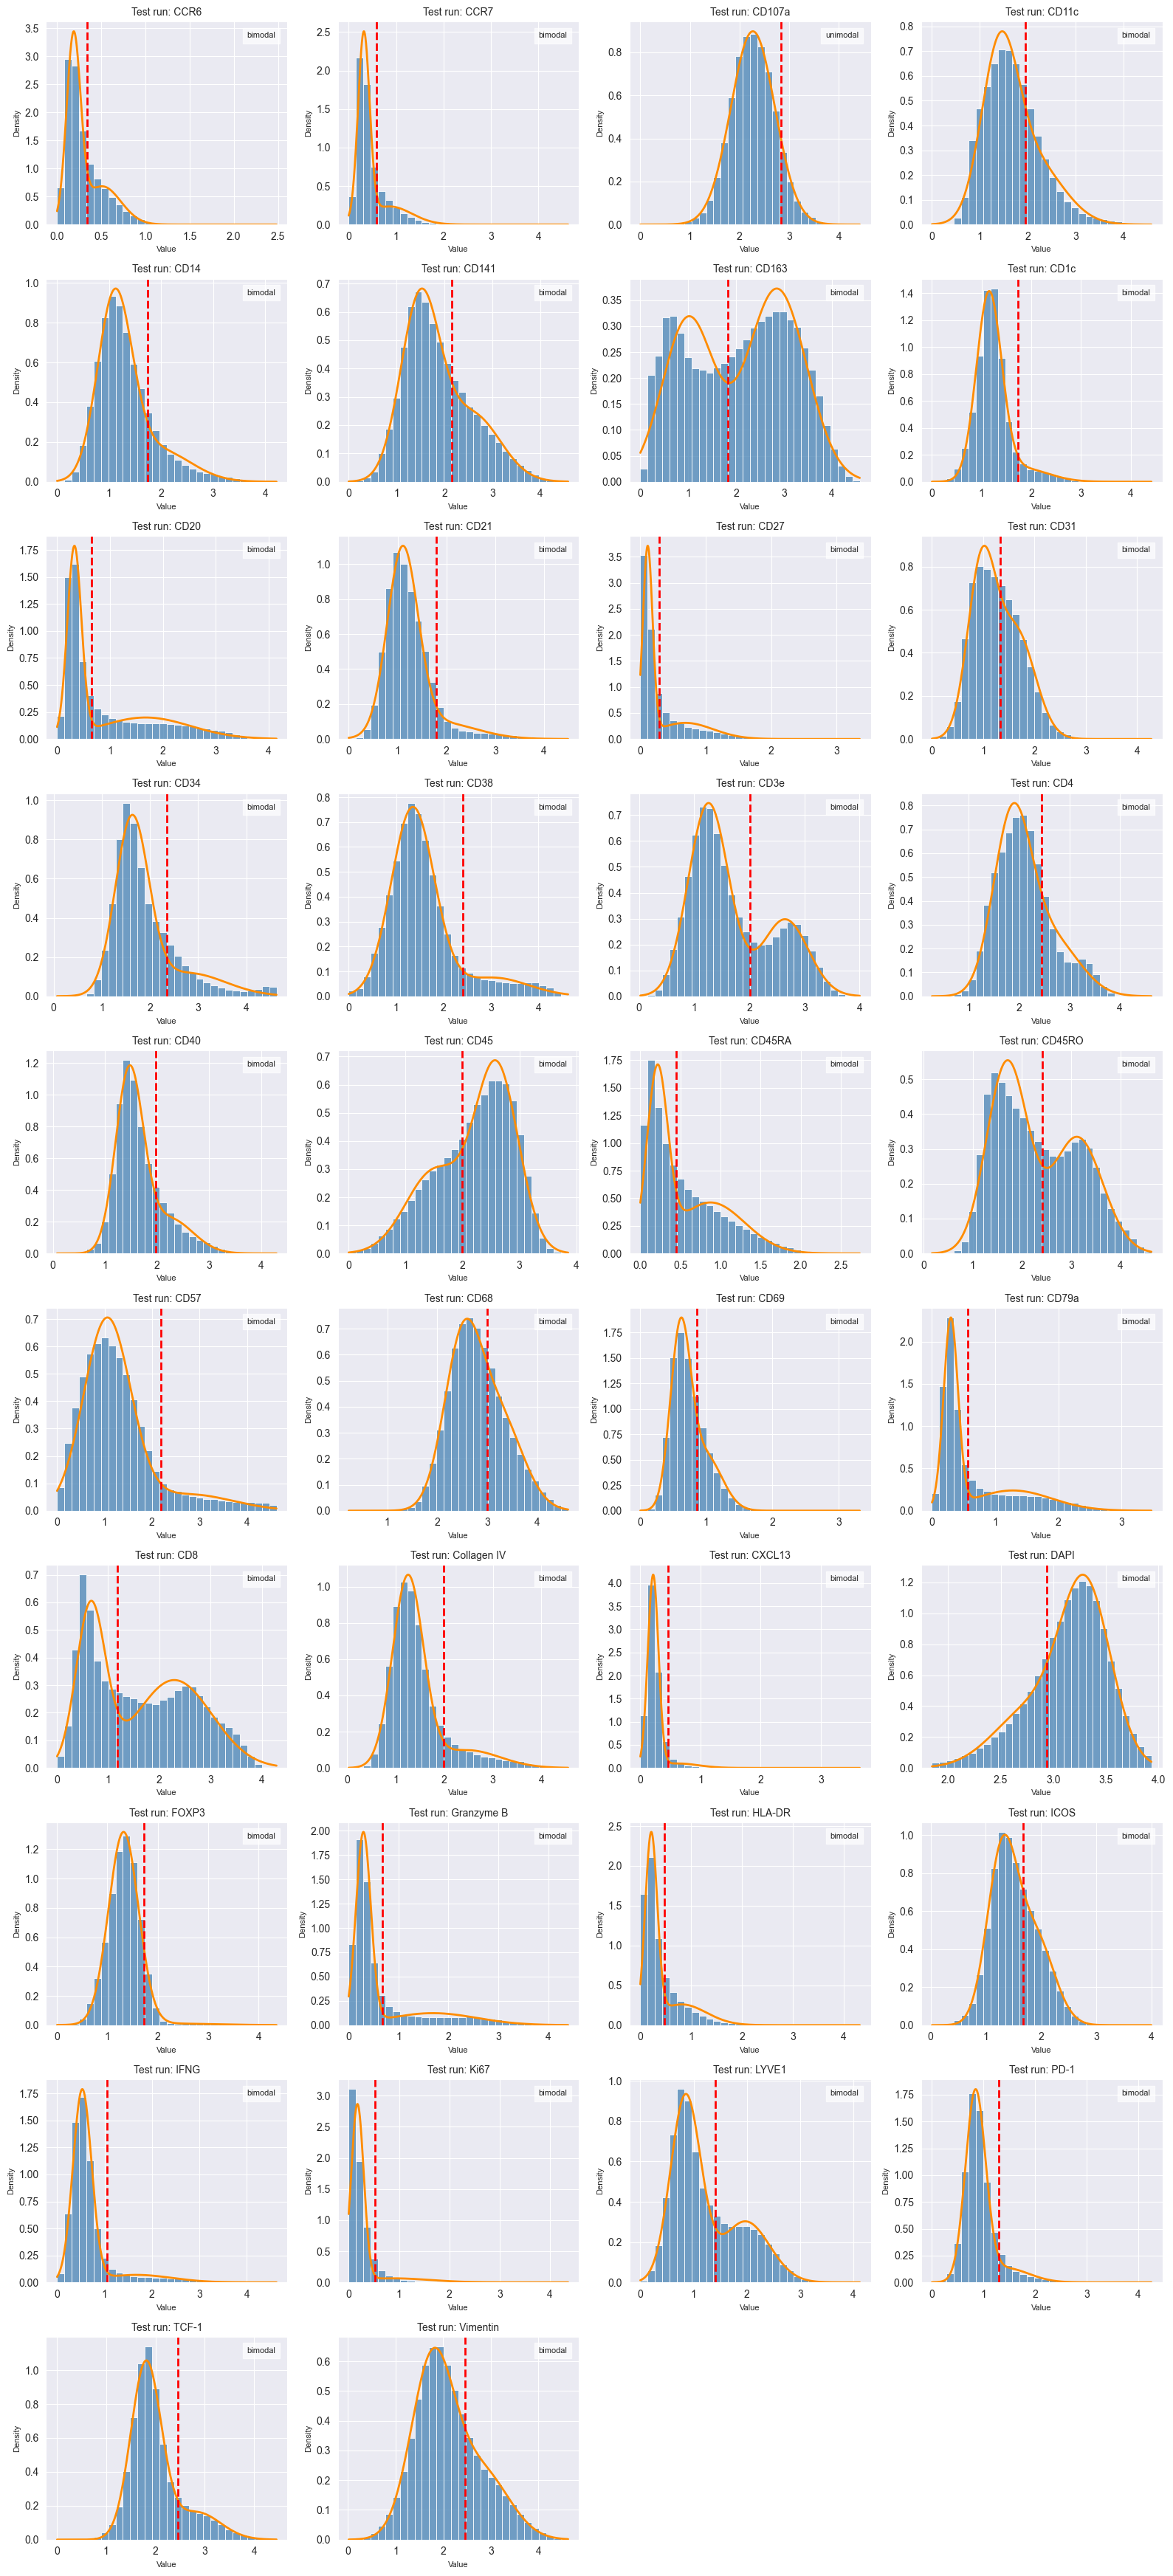

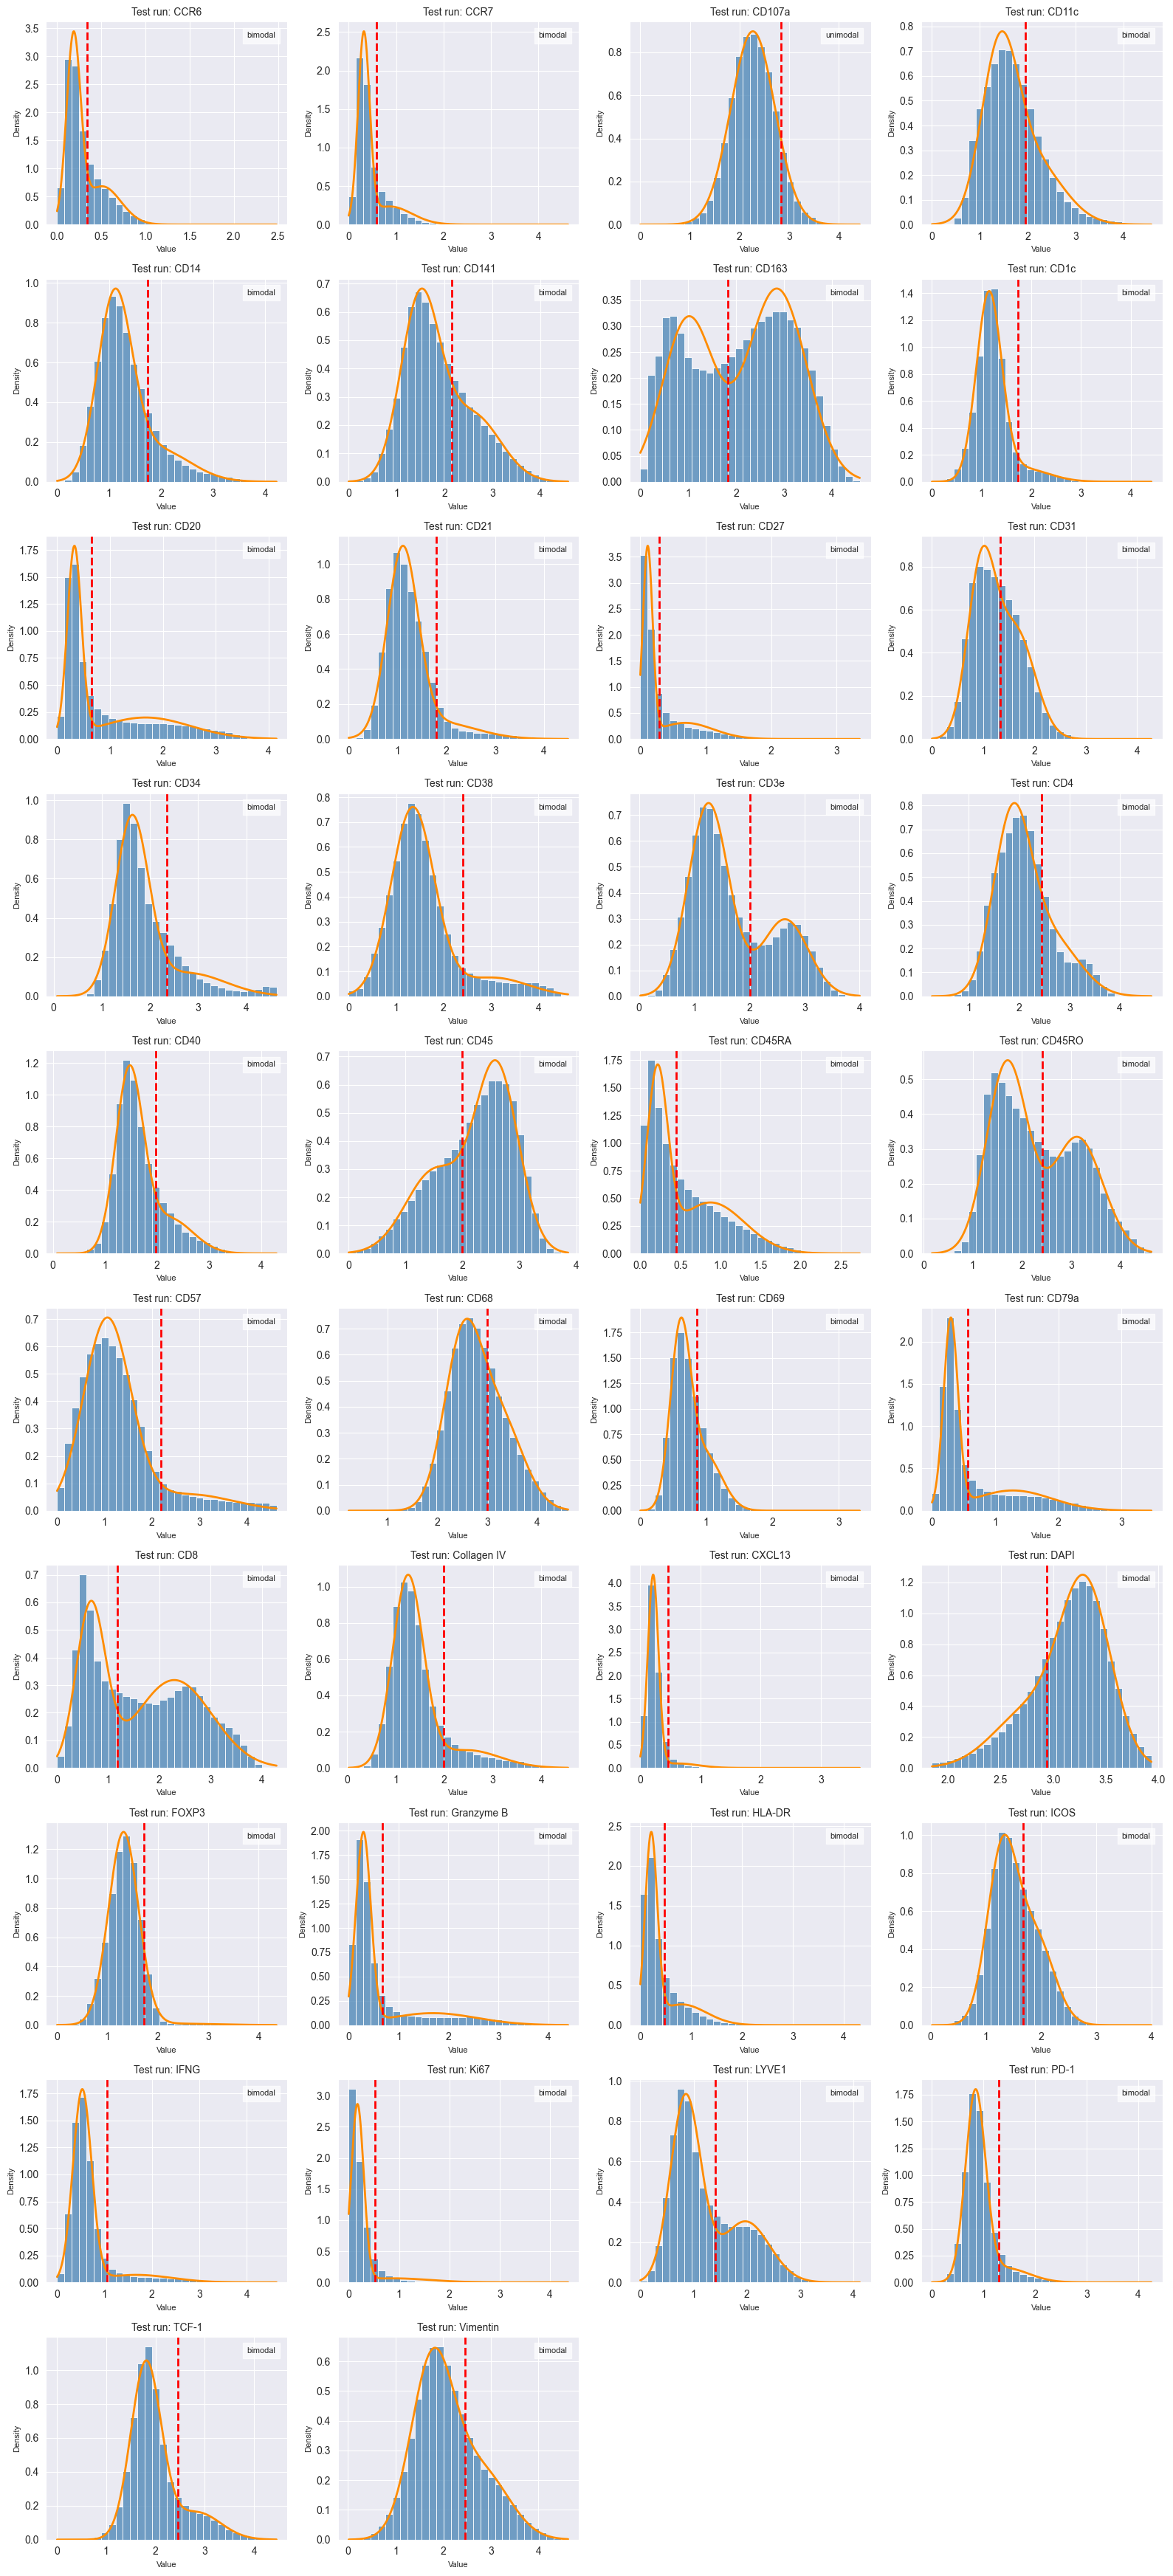

In [13]:
from scripts.annotation import plot_marker_gmm_adata
# TODO: Manually set threshold based on spatial look?
plot_marker_gmm_adata(adata,
                      thresholds,
                      best_gmms,
                      title_prefix="Test run: ",
                      save=False,
                      filename="testing_GMM")

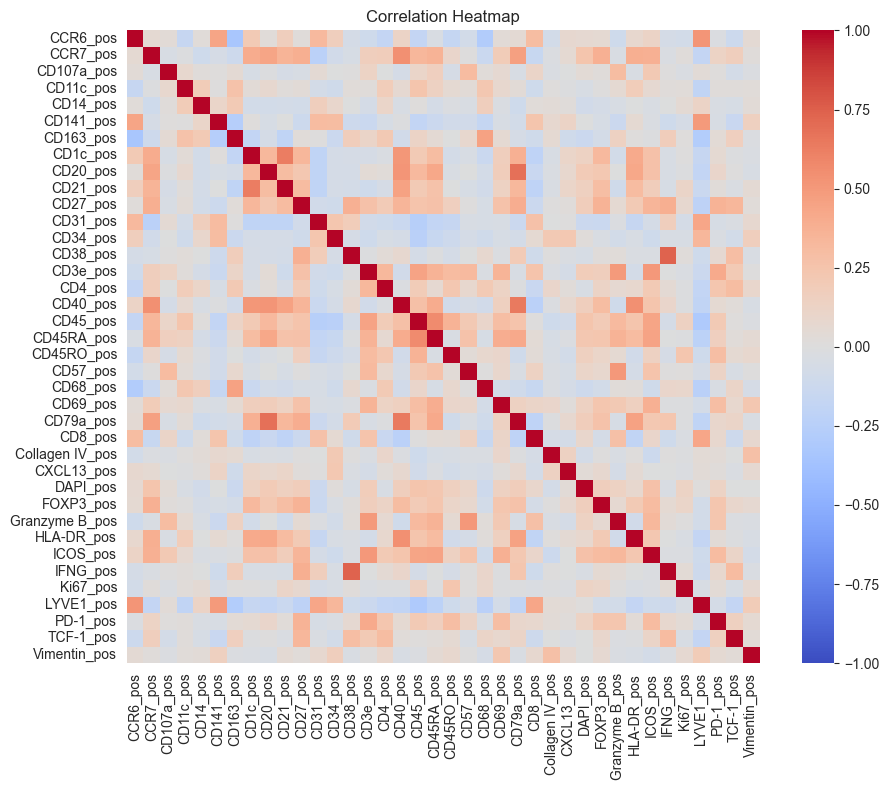

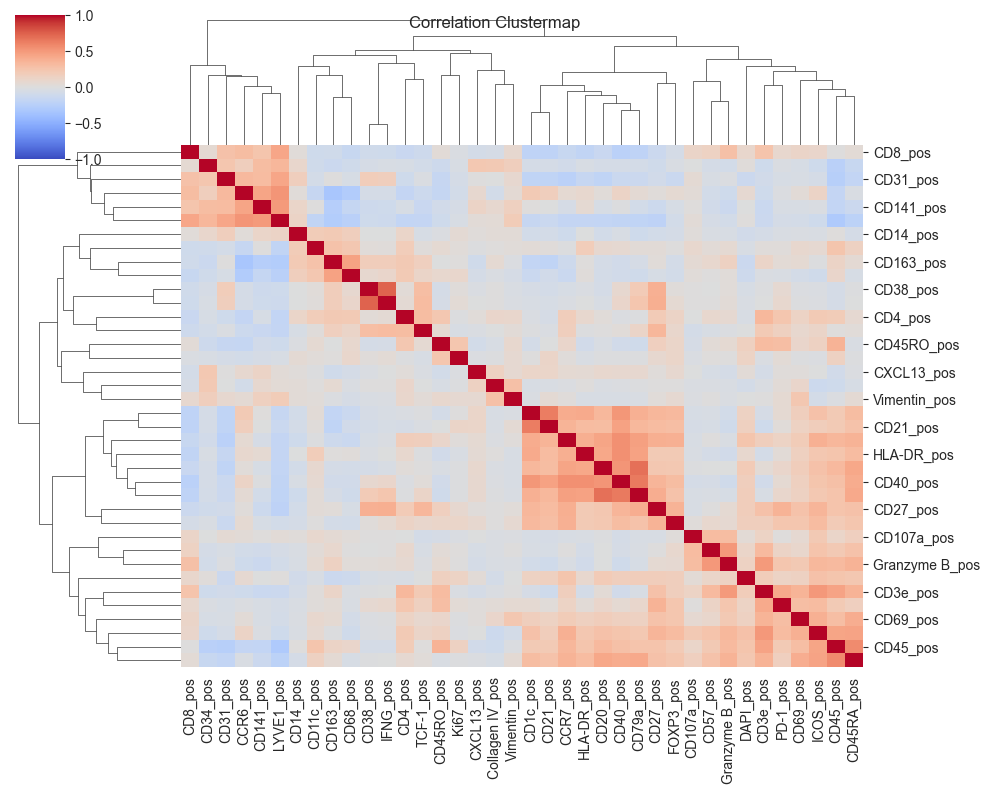

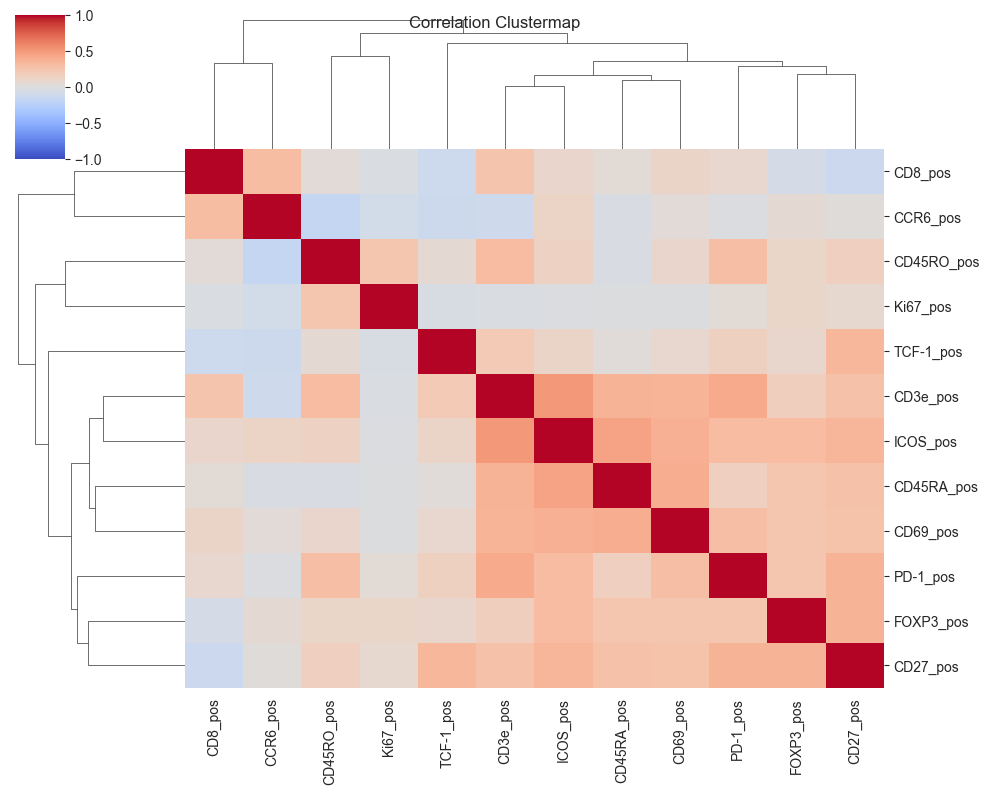

,CD3e_pos,FOXP3_pos,ICOS_pos,CD8_pos,CD45RO_pos,CD45RA_pos,TCF-1_pos,CD27_pos,CD69_pos,PD-1_pos,CCR6_pos,Ki67_pos
CD3e_pos,1.000000,0.167066,0.503759,0.252662,0.307992,0.359892,0.207283,0.267690,0.353919,0.411091,-0.103753,-0.026730
FOXP3_pos,0.167066,1.000000,0.305105,-0.068463,0.104879,0.237832,0.092424,0.363761,0.242178,0.238360,0.059429,0.106583
ICOS_pos,0.503759,0.305105,1.000000,0.101242,0.141375,0.450585,0.114323,0.347285,0.382803,0.311713,0.120508,-0.018999
CD8_pos,0.252662,-0.068463,0.101242,1.000000,0.032352,0.044219,-0.113211,-0.125972,0.111125,0.079704,0.303531,-0.029269
CD45RO_pos,0.307992,0.104879,0.141375,0.032352,1.000000,-0.032902,0.057601,0.160411,0.098615,0.294654,-0.168891,0.237868
CD45RA_pos,0.359892,0.237832,0.450585,0.044219,-0.032902,1.000000,0.025899,0.271535,0.395947,0.160815,-0.032838,-0.008442
TCF-1_pos,0.207283,0.092424,0.114323,-0.113211,0.057601,0.025899,1.000000,0.341852,0.083327,0.154347,-0.118328,-0.040391
CD27_pos,0.267690,0.363761,0.347285,-0.125972,0.160411,0.271535,0.341852,1.000000,0.260683,0.361794,0.023092,0.076950
CD69_pos,0.353919,0.242178,0.382803,0.111125,0.098615,0.395947,0.083327,0.260683,1.000000,0.295670,0.037200,-0.011900
PD-1_pos,0.411091,0.238360,0.311713,0.079704,0.294654,0.160815,0.154347,0.361794,0.295670,1.000000,-0.021508,0.039072


In [50]:
from scripts.plotting import marker_correlation_plots

marker_correlation_plots(adata)
marker_correlation_plots(adata, use_clustermap=True)
# Clustermap uses UPGMA algorithm via scipy.cluster.hierarchy.linkage(method = "average")

# Select markers:
tc_markers = ["CD3e", "FOXP3", "ICOS", "CD8", "CD45RO", "CD45RA", "TCF-1", "CD27", "CD69", "PD-1", "CCR6", "GranzymeB", "Ki67"]
marker_correlation_plots(adata, markers=tc_markers, use_clustermap=True)

Spatially mapping one marker:

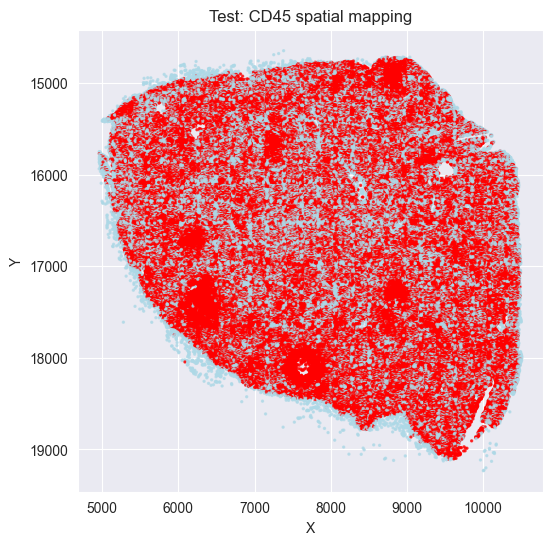

In [19]:
from scripts.spatialmapping import plot_spatial_marker

# Plot CD45+ vs CD45-
plot_spatial_marker(adata, "CD45", thresholded=True, title_prefix="Test: ", color_hi="red", color_lo="lightblue")

# TODO: Percentage CD45+
# TODO: Try to make a version where we can just plug in multiple +/- markers of choice? Start with the excel table anyway

Assign cell types:

In [32]:
from scripts.celltype_rules import assign_cell_types

# Annotate all cells
adata = assign_cell_types(adata)

/Users/magnusberg/Documents/Internships/fall 2025/IHOPE_SpatialProteomics/scripts/celltype_rules.py:62: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['type'] = 'Unclassified_type'


Dropped cells (no CD45 info): 0
CD45+ (Immune): 121943
CD45- (Non-Immune): 65154
T-cells: 29518
B-cells: 40108
Myeloid: 13075
Immune_Unclassified: 40095
Endothelial: 48850
Stromal: 6485
Non-Immune_Unclassified: 12131
T-cell subtypes summary:
    Treg: 2
    TfH_like: 12
    Th17_like: 56
    CD4_T: 3005
    CD8_T: 16006
    Stem_like_memory_T: 0
    Naive_T: 1825
    Tissue_Resident_T: 8424
    T_Unclassified: 188
B-cell subtypes summary:
    Memory_B: 15846
    Plasma_like: 783
    GC_like_B: 582
    Follicular_like_B: 2425
    Activated_B: 11553
    B_Unclassified: 8066
Myeloid/APC subtypes summary:
    Monocyte/Macrophage: 11860
    cDC1: 533
    cDC2: 9
    Myeloid_Unclassified: 673
Non-immune subtypes summary:
    Endothelial: 1363
    Lymphatic_Endothelial: 28794
    Fibroblast: 2419
    FDC: 37
    Stromal_Unclassified: 20060
    Basement Membrane: 12481


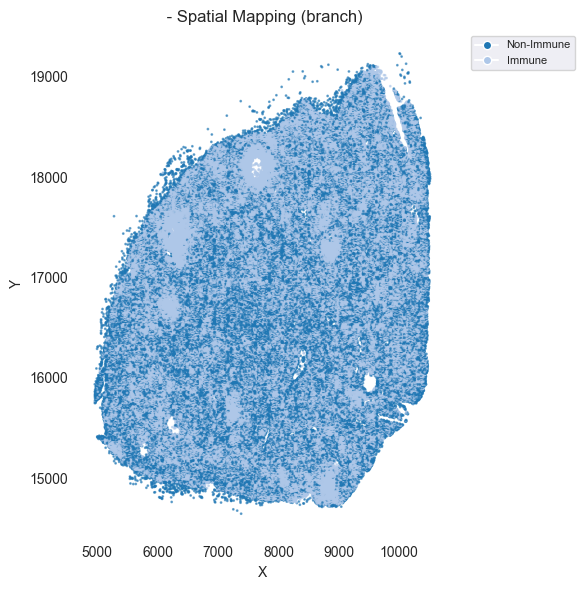

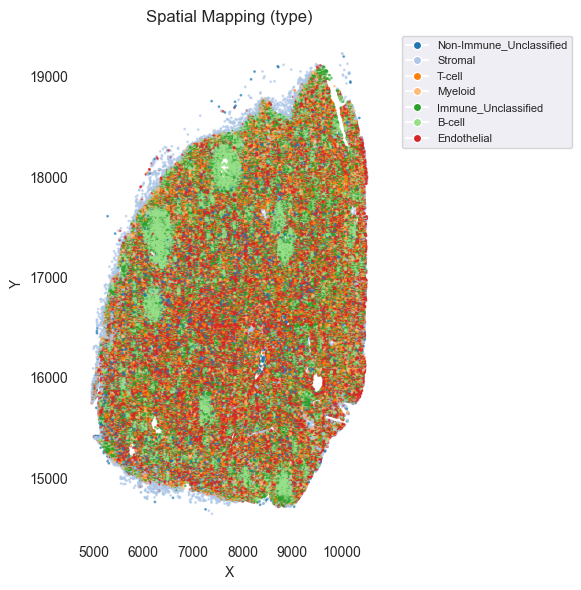

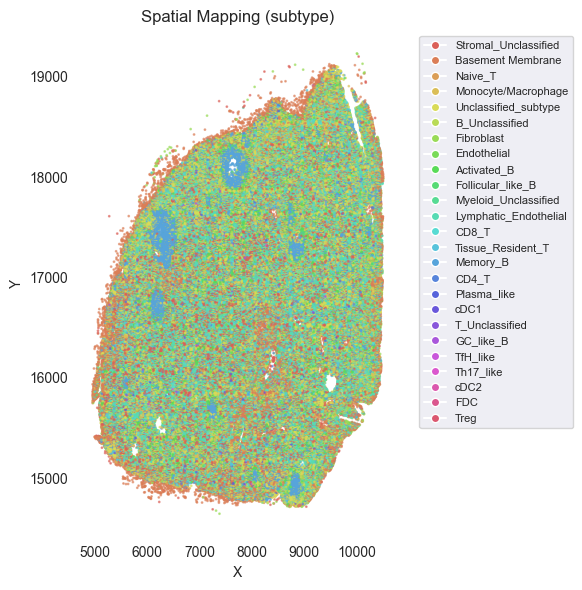

In [33]:
from scripts.spatialmapping import plot_spatial_cell_types

# Plot the branch level (immune/non-immune)
fig = plot_spatial_cell_types(
    adata,
    level="branch",
    size=1,
    alpha=0.6,
    invert_y=False,
    title_prefix=f" - ",
    save = False
)

# Plot the cell type level
fig_type = plot_spatial_cell_types(
    adata,
    level="type",
    size=1,
    alpha=0.6,
    invert_y=False,
    save = False
)

# Plot the cell subtype level
fig_subtype = plot_spatial_cell_types(
    adata,
    level="subtype",
    size=1,
    alpha=0.6,
    invert_y=False,
    save = False
)

**EXPERIMENT WITH THE FOLLOWING:**

**Cell types:**

'Endothelial', 'Stromal', 'Non-Immune_Unclassified'
'T-cell', 'B-cell', 'Myeloid', 'Immune_Unclassified'

**Cell subtypes:**

'Endothelial', 'Lymphatic_Endothelial', 'Fibroblast', 'FDC', 'Stromal_Unclassified', 'Basement Membrane'
'Monocyte/Macrophage', 'cDC1', 'cDC2', 'Myeloid_Unclassified'
'Memory_B', 'Plasma_like', 'GC_like_B', 'Follicular_like_B', 'Activated_B', 'B_Unclassified'
'Treg', 'TfH_like', 'Th17_like', 'CD4_T', 'CD8_T', 'Stem_like_memory_T', 'Naive_T', 'Tissue_Resident_T', 'T_Unclassified'

Saved to /Users/magnusberg/Documents/Internships/fall 2025/IHOPE_SpatialProteomics/results/figures/spatial_subset_type.png


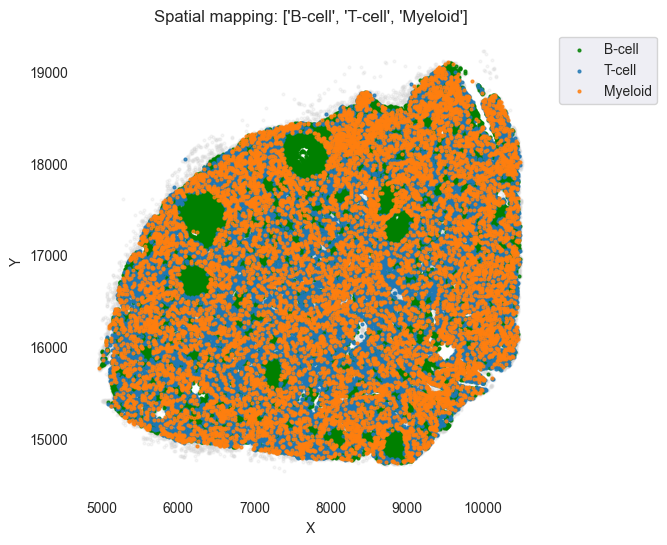

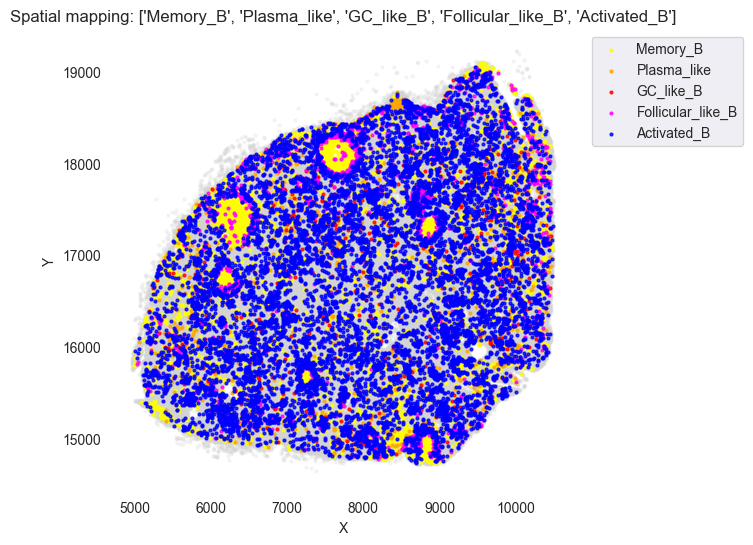

In [38]:
from scripts.spatialmapping import plot_spatial_subset

plot_spatial_subset(
    adata,
    level="type",
    include=["B-cell", "T-cell", "Myeloid"],
    colors={"B-cell": "green"},
    save = True
)

plot_spatial_subset(
    adata,
    level="subtype",
    include=["Memory_B", "Plasma_like", "GC_like_B", "Follicular_like_B", "Activated_B"],
    colors={"Memory_B": "yellow", "Plasma_like": "orange", "GC_like_B": "red", "Follicular_like_B": "magenta", "Activated_B": "blue"},
    save = False
)


# BANKSY

In [ ]:
import scanpy as sc
from banksy.initialize_banksy import initialize_banksy
from banksy.run_banksy import run_banksy_multiparam

# Load your spatial transcriptomics data
adata = sc.read_h5ad(adata)

# Initialize BANKSY
coord_keys = ('x', 'y', 'spatial')  # Adjust based on your data
banksy_dict = initialize_banksy(
    adata,
    coord_keys=coord_keys,
    num_neighbours=15,
    nbr_weight_decay='scaled_gaussian'
)

# Run BANKSY clustering

results_df = run_banksy_multiparam(
    adata,
    banksy_dict,
    lambda_list=[0.2],
    resolutions=[0.5, 1.0]
)